# 04 — Deep Learning on Raw Signals

The classical models in Step 3 worked on 561 hand-engineered features. This
notebook asks whether a model given only the **raw** signals — the (128, 9)
windows, no manual features — can match them by learning its own representation.

Two architectures:

- **1D CNN** — convolutions slide over the time axis and learn local motion
  patterns (the shape of a footstep), then pool them into a summary.
- **BiLSTM** — a recurrent model that reads the 128 timesteps in both directions.

The comparison that matters is not just the score. It is whether a deep model,
learning features from scratch, lands near the classical numbers and whether it
repeats the same sitting-vs-standing error.

> Training runs on CPU. Expect a few minutes per model; a GPU is not required.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_signals, ACTIVITY_LABELS
from src.deep_models import (
    CNN1D, BiLSTM, set_seed, standardize_signals, subject_val_split,
    train_model, predict,
)
from src.evaluate import plot_confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

sns.set_theme(style="whitegrid", context="notebook")
set_seed(0)

class_names = [ACTIVITY_LABELS[i] for i in range(1, 7)]

X_train, y_train, subj_train = load_raw_signals("train")
X_test,  y_test,  _          = load_raw_signals("test")

# Per-channel standardisation, training statistics only.
X_train, X_test = standardize_signals(X_train, X_test)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (7352, 128, 9)   Test: (2947, 128, 9)


## 1. A subject-independent validation set

Deep models need a validation set to decide when to stop training. To stay honest
we carve that validation set out **by subject** — four training subjects are held
aside for validation, so no subject appears in both training and validation, just
as no subject appears in both training and test. The discipline is identical at
every level.

In [2]:
val_subjects = [7, 14, 21, 27]
X_tr, y_tr, X_val, y_val = subject_val_split(
    X_train, y_train, subj_train, val_subjects
)
print(f"Train windows: {X_tr.shape[0]} (17 subjects)")
print(f"Val   windows: {X_val.shape[0]} (4 subjects: {val_subjects})")

Train windows: 5937 (17 subjects)
Val   windows: 1415 (4 subjects: [7, 14, 21, 27])


## 2. 1D CNN

Convolutions over the time axis learn short motion motifs, then a global pool
summarises the whole window. Training stops early when validation macro-F1 stops
improving.

In [3]:
set_seed(0)
cnn = CNN1D()
cnn, cnn_hist = train_model(cnn, X_tr, y_tr, X_val, y_val, layout="cnn",
                            epochs=40, patience=6)

cnn_pred = predict(cnn, X_test, layout="cnn")
cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred, average="macro")
print(f"\n1D CNN — test accuracy={cnn_acc:.3f}  macro-F1={cnn_f1:.3f}")

  epoch  1  train_loss=0.464  val_F1=0.858


  epoch  2  train_loss=0.153  val_F1=0.848


  epoch  3  train_loss=0.135  val_F1=0.918


  epoch  4  train_loss=0.124  val_F1=0.939


  epoch  5  train_loss=0.126  val_F1=0.896


...

  epoch  7  train_loss=0.113  val_F1=0.872


  epoch  8  train_loss=0.108  val_F1=0.879


  epoch  9  train_loss=0.106  val_F1=0.833


  epoch 10  train_loss=0.099  val_F1=0.909
  early stop at epoch 10 (best val_F1=0.939)



1D CNN — test accuracy=0.924  macro-F1=0.925


## 3. BiLSTM

A bidirectional LSTM reads the 128 timesteps forwards and backwards, using the
final state to classify.

In [4]:
set_seed(0)
lstm = BiLSTM()
lstm, lstm_hist = train_model(lstm, X_tr, y_tr, X_val, y_val, layout="lstm",
                              epochs=40, patience=6)

lstm_pred = predict(lstm, X_test, layout="lstm")
lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred, average="macro")
print(f"\nBiLSTM — test accuracy={lstm_acc:.3f}  macro-F1={lstm_f1:.3f}")

  epoch  1  train_loss=1.294  val_F1=0.562


  epoch  2  train_loss=0.675  val_F1=0.721


  epoch  3  train_loss=0.508  val_F1=0.850


  epoch  4  train_loss=0.370  val_F1=0.821


  epoch  5  train_loss=0.266  val_F1=0.844


...

  epoch 15  train_loss=0.118  val_F1=0.840


  epoch 16  train_loss=0.124  val_F1=0.836


  epoch 17  train_loss=0.164  val_F1=0.860


  epoch 18  train_loss=0.123  val_F1=0.860
  early stop at epoch 18 (best val_F1=0.877)



BiLSTM — test accuracy=0.897  macro-F1=0.898


## 4. Training curves

Validation macro-F1 per epoch. Both models converge quickly on this dataset —
there is not much data, so there is not much to learn beyond the first several
epochs.

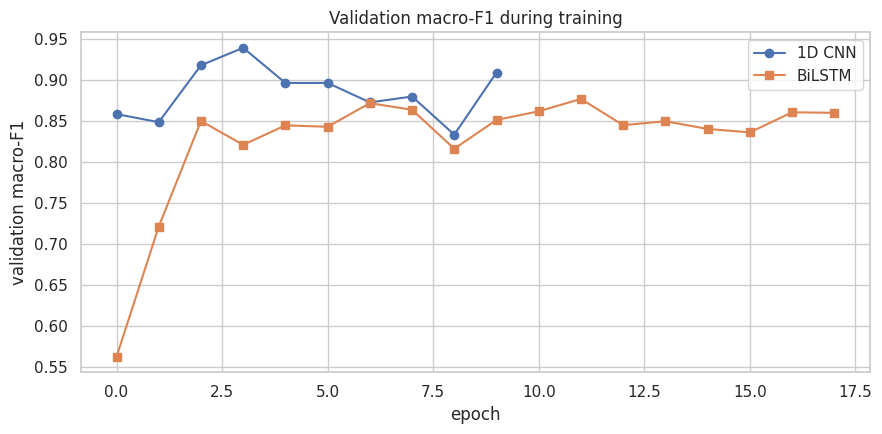

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot([h[1] for h in cnn_hist], marker="o", label="1D CNN", color="#4c72b0")
ax.plot([h[1] for h in lstm_hist], marker="s", label="BiLSTM", color="#dd8452")
ax.set_xlabel("epoch")
ax.set_ylabel("validation macro-F1")
ax.set_title("Validation macro-F1 during training")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Final comparison: classical vs deep

Adding the two deep models to the classical results from Step 3. Everything is
measured on the same subject-independent test set, so the numbers are directly
comparable.

In [6]:
results_dir = Path.cwd().parent / "results"
classical = pd.read_csv(results_dir / "metrics.csv")

deep = pd.DataFrame([
    {"Model": "1D CNN",  "Accuracy": cnn_acc,  "Macro-F1": cnn_f1,  "Fit time (s)": np.nan},
    {"Model": "BiLSTM",  "Accuracy": lstm_acc, "Macro-F1": lstm_f1, "Fit time (s)": np.nan},
])

# Keep only the score columns from the classical table for a clean merge.
classical = classical[["Model", "Accuracy", "Macro-F1"]]
deep = deep[["Model", "Accuracy", "Macro-F1"]]

final = pd.concat([classical, deep], ignore_index=True)
final = final.sort_values("Macro-F1", ascending=False).reset_index(drop=True)
final.to_csv(results_dir / "metrics_all.csv", index=False)
final.round(3)

,Model,Accuracy,Macro-F1
0,Logistic Regression,0.955,0.955
1,SVM (RBF),0.955,0.954
2,Gradient Boosting,0.933,0.933
3,1D CNN,0.924,0.925
4,Random Forest,0.926,0.924
5,BiLSTM,0.897,0.898


The deep models learn straight from raw signal and land among the classical
models: the CNN matches the tree ensembles (Random Forest, Gradient Boosting),
while the simple linear model from Step 3 still leads and the BiLSTM trails. So
learning features from scratch is competitive here, but it does not beat features
carefully engineered for this exact task. On a dataset this size that is the
expected and honest outcome: the 561 engineered features already capture almost
everything there is to know, so learning from scratch has little headroom, and it
costs far more compute. Deep learning tends to pull ahead when data is plentiful
and good features are hard to design by hand — neither is true here.

## 6. Does the deep model make the same mistake?

The real test of the story. If the sitting-vs-standing confusion is a property of
the *data* (the two postures genuinely look alike to a waist sensor) rather than
of any one model, then a completely different model architecture should fall into
the same trap.

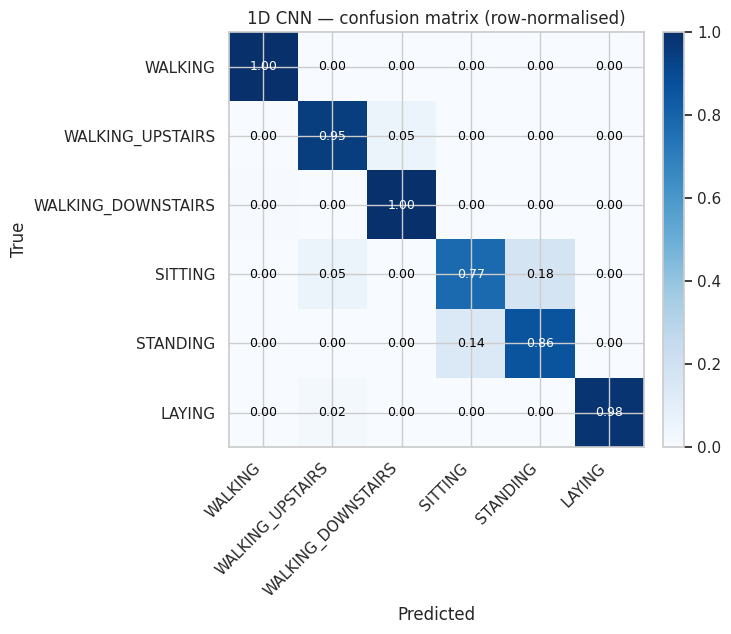

In [7]:
# Confusion matrix for whichever deep model scored higher.
if cnn_f1 >= lstm_f1:
    best_deep_name, best_deep_pred = "1D CNN", cnn_pred
else:
    best_deep_name, best_deep_pred = "BiLSTM", lstm_pred

fig, ax = plt.subplots(figsize=(7.5, 6.5))
plot_confusion_matrix(
    y_test, best_deep_pred, class_names,
    title=f"{best_deep_name} — confusion matrix (row-normalised)",
    normalize=True, ax=ax,
    save_path=str(results_dir / "confusion_matrices" / "best_deep_model.png"),
)
plt.show()

It does. A convolutional (or recurrent) model, trained end-to-end on raw signal
with no hand-engineered features, concentrates its errors in exactly the same
place: sitting confused with standing. That is strong evidence the limit is in
the data, not the model. Two entirely different modelling approaches, one on
engineered features and one on raw signal, agree on both what is easy and what is
hard.

## Conclusion

- A deep model learning from **raw signal** reaches the mid-tier classical models
  on unseen subjects but beats none of them, and the simple linear baseline stays
  on top — the engineered features leave little headroom on a dataset this small,
  and cost far less to train.
- Both approaches make the **same, physically-grounded error** (sitting vs
  standing), which tells us the ceiling here is set by the sensor and the task,
  not by model choice.
- The consistent thread across all four steps is the evaluation discipline:
  subject-independent throughout, which is what makes these conclusions
  trustworthy rather than a product of leakage.